In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('../data/processed/rossmann_features.csv', parse_dates=['Date'])
forecast = pd.read_csv('../data/processed/sales_forecast.csv', parse_dates=['Date'])

## --- CHART 1: Monthly sales trend (all stores) ---

In [4]:
monthly = df.groupby(pd.Grouper(key='Date', freq='ME'))['Sales'].sum() / 1e6

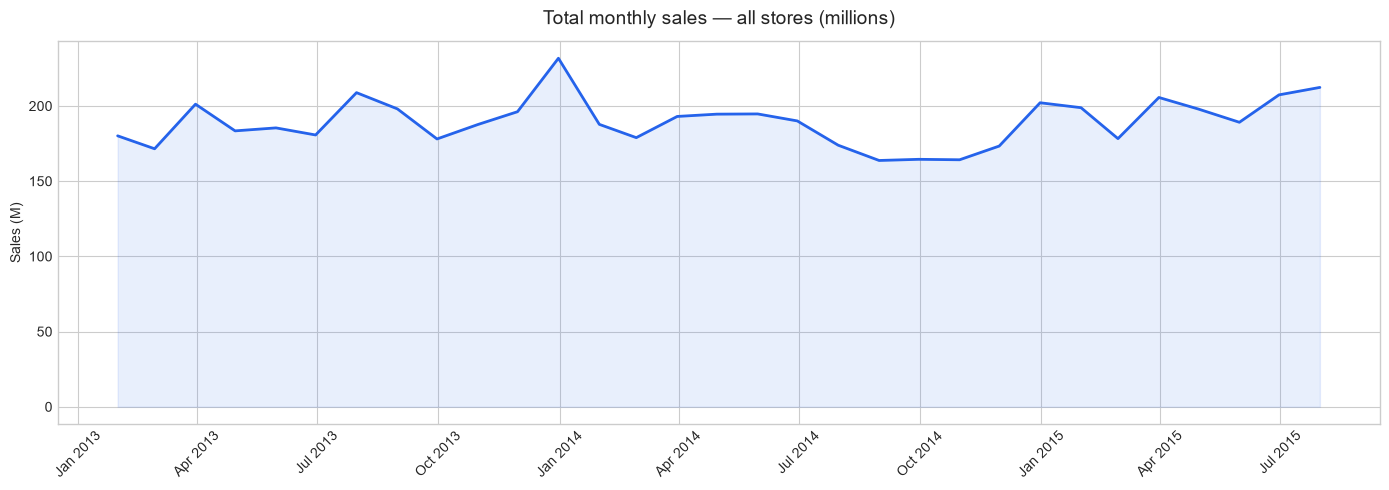

Chart 1 saved.


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values, linewidth=2, color='#2563eb')
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color='#2563eb')
ax.set_title('Total monthly sales — all stores (millions)', fontsize=14, pad=12)
ax.set_ylabel('Sales (M)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/dashboard_monthly_trend.png', dpi=150)
plt.show()
print("Chart 1 saved.")

## --- CHART 2: Sales by day of week ---

In [ ]:

dow_avg = df.groupby('DayOfWeek')['Sales'].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

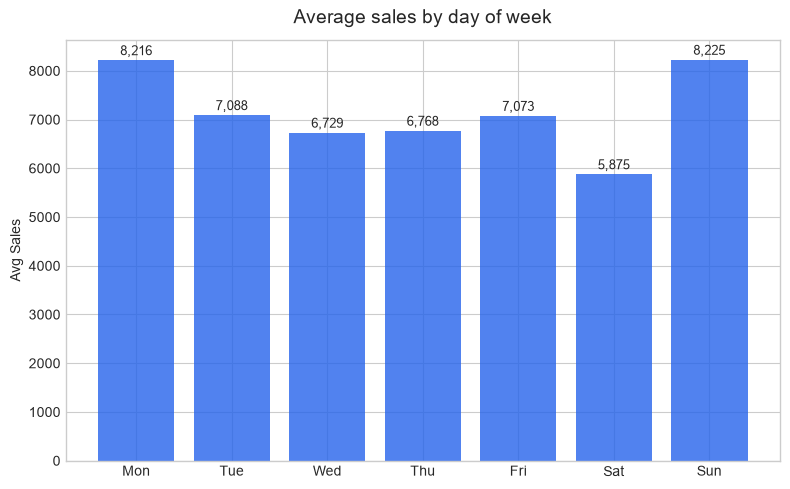

Chart 2 saved.


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(days, dow_avg.values, color='#2563eb', alpha=0.8)
ax.set_title('Average sales by day of week', fontsize=14, pad=12)
ax.set_ylabel('Avg Sales')
for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/dashboard_day_of_week.png', dpi=150)
plt.show()
print("Chart 2 saved.")

## --- CHART 3: Promo impact ---

In [8]:
promo_avg = df.groupby('Promo')['Sales'].mean()
labels = ['No Promo', 'Promo Active']

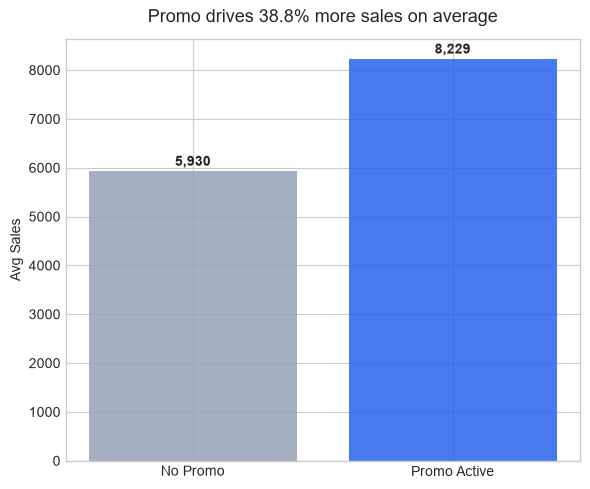

Chart 3 saved.


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, promo_avg.values, color=['#94a3b8','#2563eb'], alpha=0.85)
ax.set_title('Average sales: promo vs no promo', fontsize=14, pad=12)
ax.set_ylabel('Avg Sales')
for bar, val in zip(bars, promo_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
pct = (promo_avg[1] - promo_avg[0]) / promo_avg[0] * 100
ax.set_title(f'Promo drives {pct:.1f}% more sales on average', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/dashboard_promo_impact.png', dpi=150)
plt.show()
print("Chart 3 saved.")

## --- CHART 4: Actual vs Predicted (full test period, top 5 stores) ---

Top 5 store IDs: [262, 1114, 562, 817, 842]
Store 262: 92 rows
Store 1114: 76 rows
Store 562: 92 rows
Store 817: 76 rows
Store 842: 75 rows


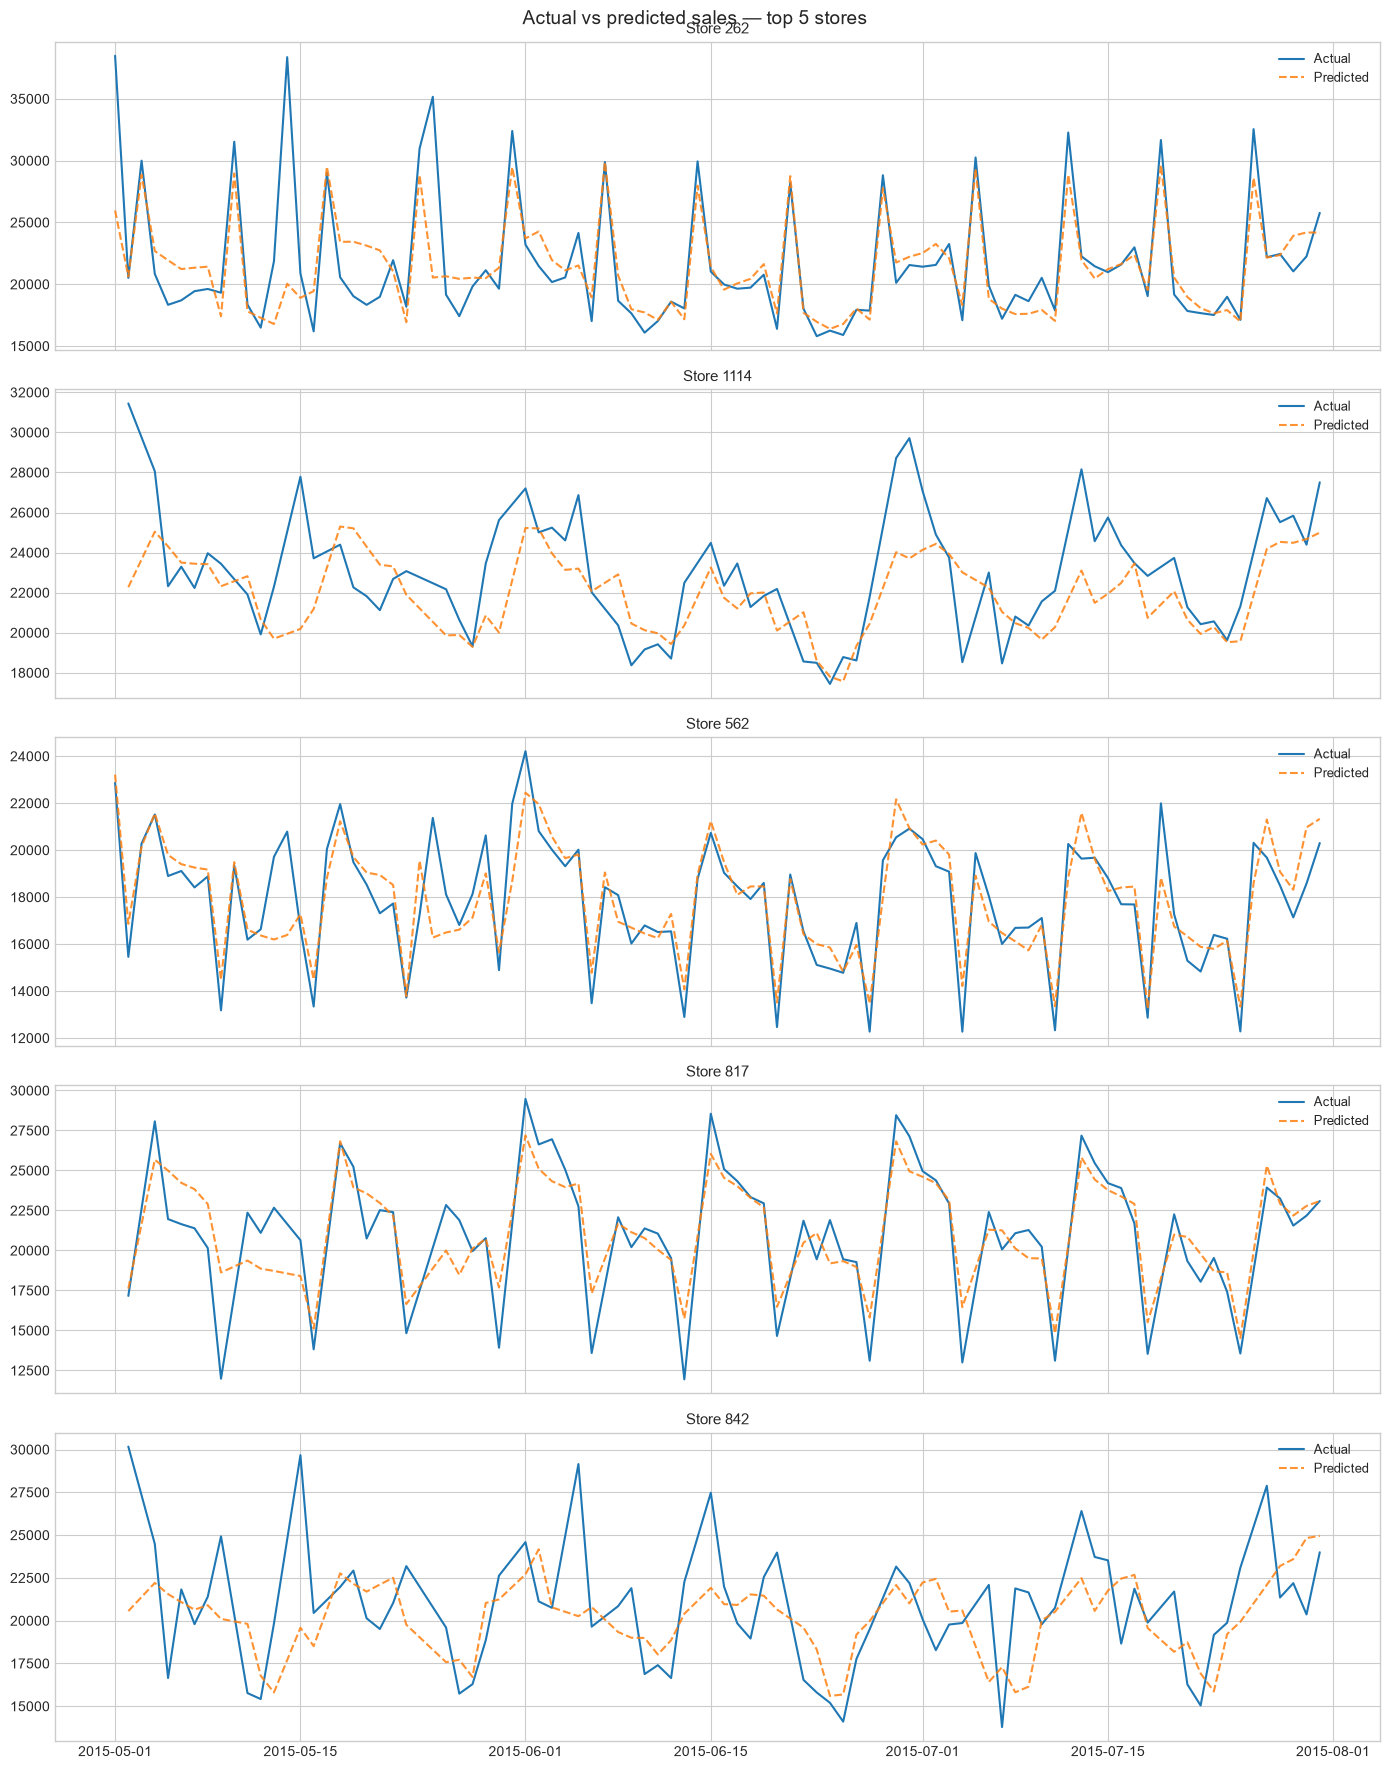

In [16]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

top5 = forecast.groupby('Store')['Predicted_Sales'].sum().nlargest(5).index.tolist()
print("Top 5 store IDs:", top5)

for ax, store_id in zip(axes, top5):
    s = forecast[forecast['Store'] == store_id].sort_values('Date')
    print(f"Store {store_id}: {len(s)} rows")
    ax.plot(s['Date'], s['Sales'], label='Actual', linewidth=1.5)
    ax.plot(s['Date'], s['Predicted_Sales'], label='Predicted',
            linewidth=1.5, linestyle='--', alpha=0.85)
    ax.set_title(f'Store {store_id}', fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle('Actual vs predicted sales — top 5 stores', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/dashboard_forecast_top5.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
for ax, store_id in zip(axes, top5):
    s = forecast[forecast['Store'] == store_id]
    ax.plot(s['Date'], s['Sales'], label='Actual', linewidth=1.5)
    ax.plot(s['Date'], s['Predicted_Sales'], label='Predicted',
            linewidth=1.5, linestyle='--', alpha=0.85)
    ax.set_title(f'Store {store_id}', fontsize=11)
    ax.legend(fontsize=9)

In [12]:
fig.suptitle('Actual vs predicted sales — top 5 stores', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/dashboard_forecast_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

<Figure size 640x480 with 0 Axes>

Chart 4 saved.


## --- CHART 5: Store type sales heatmap (month x store type) ---

In [13]:
heat = df.groupby(['StoreType', pd.Grouper(key='Date', freq='ME')])['Sales'].mean().unstack(0)

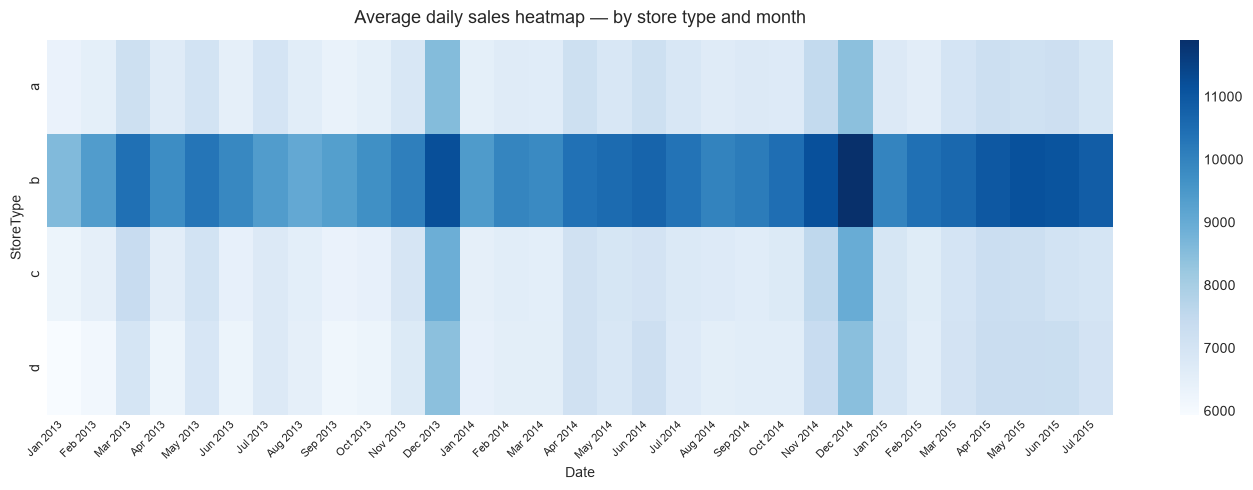

Chart 5 saved.


In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat.T, ax=ax, cmap='Blues', fmt='.0f',
            xticklabels=[d.strftime('%b %Y') for d in heat.index])
ax.set_title('Average daily sales heatmap — by store type and month', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/dashboard_heatmap_storetype.png', dpi=150)
plt.show()
print("Chart 5 saved.")

## Getting values for final report

In [17]:
forecast = pd.read_csv('../data/processed/sales_forecast.csv')
total = forecast['Predicted_Sales'].sum()
top10 = forecast.groupby('Store')['Predicted_Sales'].sum().nlargest(10).sum()
print(f"Top 10 stores: {top10/total*100:.1f}% of total predicted revenue")

Top 10 stores: 2.5% of total predicted revenue


In [18]:
forecast = pd.read_csv('../data/processed/sales_forecast.csv')
total = forecast['Predicted_Sales'].sum()
top10 = forecast.groupby('Store')['Predicted_Sales'].sum().nlargest(10).sum()
print(f"Total predicted revenue: {total:,.0f}")
print(f"Top 10 stores revenue: {top10:,.0f}")
print(f"Top 10 stores: {top10/total*100:.1f}%")

# Also check top 10 store IDs and their individual totals
print(forecast.groupby('Store')['Predicted_Sales'].sum().nlargest(10))

Total predicted revenue: 604,711,277
Top 10 stores revenue: 15,339,122
Top 10 stores: 2.5%
Store
262     1.969871e+06
1114    1.668571e+06
562     1.646812e+06
817     1.616504e+06
842     1.513984e+06
251     1.457028e+06
733     1.403649e+06
788     1.392745e+06
513     1.370781e+06
383     1.299178e+06
Name: Predicted_Sales, dtype: float64
